In [11]:
!pip install mlflow scikit-learn matplotlib seaborn 
!mlflow --version

mlflow, version 3.12.0


In [12]:
import mlflow
import mlflow.sklearn

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('All imports OK')

All imports OK


Dataset shape : (1797, 64)
Classes       : [0 1 2 3 4 5 6 7 8 9]
Image size    : 8x8 pixels flattened to 64 features


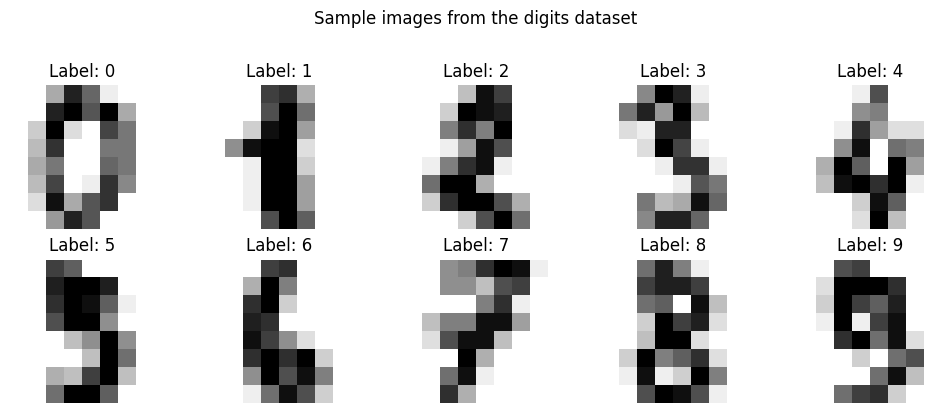

Saved sample_digits.png


In [13]:
digits = load_digits()
X, y = digits.data, digits.target

print(f'Dataset shape : {X.shape}')   # (1797, 64)
print(f'Classes       : {np.unique(y)}')
print(f'Image size    : 8x8 pixels flattened to 64 features')

# Visualise a few samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Sample images from the digits dataset', y=1.02)
plt.tight_layout()
plt.savefig('sample_digits.png', bbox_inches='tight')
plt.show()
print('Saved sample_digits.png')

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train samples : {len(X_train)}')
print(f'Test samples  : {len(X_test)}')

Train samples : 1437
Test samples  : 360


In [15]:
# Name your experiment — MLflow creates it if it doesn't exist
mlflow.set_experiment('digit-classifier')

print('Experiment set: digit-classifier')
print('Runs will be saved to ./mlruns/')

Experiment set: digit-classifier
Runs will be saved to ./mlruns/


mlflow.autolog() -> recommended as it logs every metric, param of each model run by default
include this command before model.start_run()

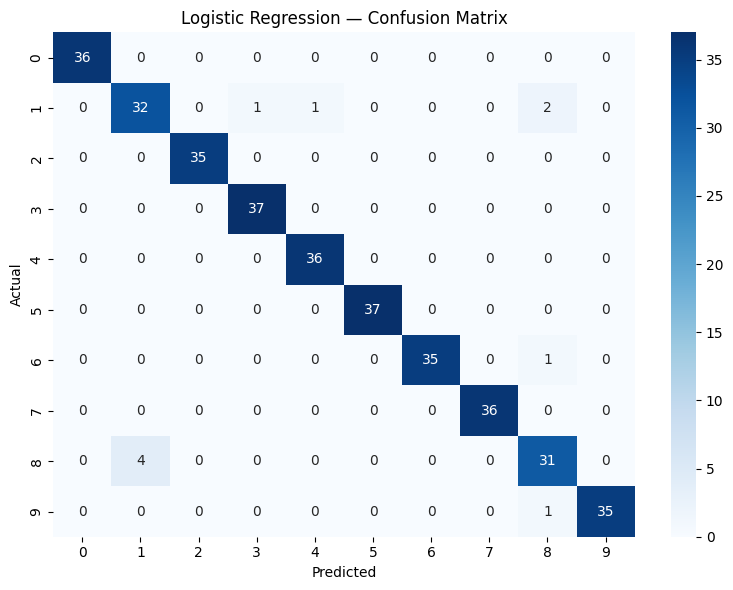

2026/05/27 13:04:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run complete — Accuracy: 0.9722  |  F1: 0.9722
Run ID: 7276db6c8db54bbabe3a6f84a7dccafb


In [16]:
with mlflow.start_run(run_name='logistic-regression'):

    # --- Params: anything that defines this run ---
    params = {'model_type': 'LogisticRegression', 'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'}
    mlflow.log_params(params)

    # --- Train ---
    model = LogisticRegression(C=params['C'], max_iter=params['max_iter'], solver=params['solver'])
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # --- Metrics ---
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('f1_score', f1)

    # --- Artifact: confusion matrix plot ---
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title('Logistic Regression — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig('confusion_matrix_lr.png')
    mlflow.log_artifact('confusion_matrix_lr.png')
    plt.show()

    # --- Log the model itself ---
    mlflow.sklearn.log_model(model, name='digit-model')

    print(f'Run complete — Accuracy: {acc:.4f}  |  F1: {f1:.4f}')
    print(f'Run ID: {mlflow.active_run().info.run_id}')

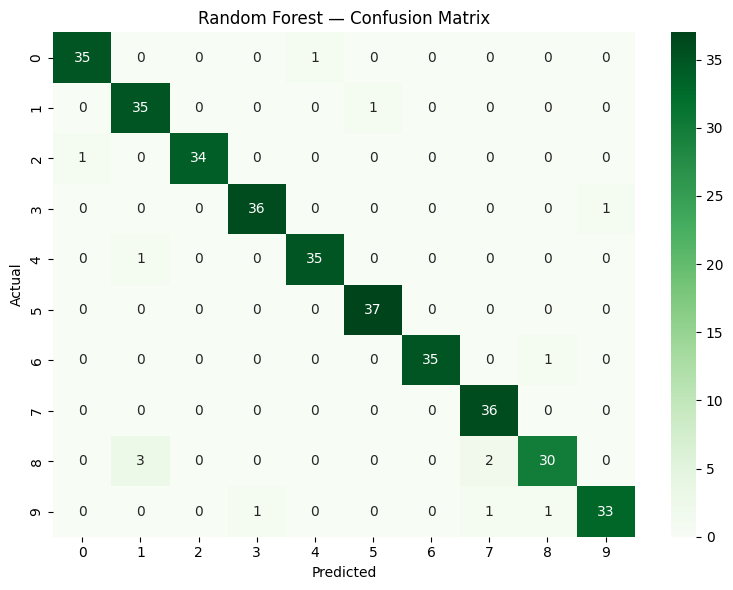

2026/05/27 13:04:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run complete — Accuracy: 0.9611  |  F1: 0.9609
Run ID: b155342a98d6439fa08c38075e348eaa


In [17]:
with mlflow.start_run(run_name='random-forest'):

    params = {'model_type': 'RandomForest', 'n_estimators': 100, 'max_depth': 10, 'random_state': 42}
    mlflow.log_params(params)

    model_rf = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        random_state=params['random_state']
    )
    model_rf.fit(X_train_scaled, y_train)
    y_pred_rf = model_rf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_rf)
    f1  = f1_score(y_test, y_pred_rf, average='weighted')
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('f1_score', f1)

    cm = confusion_matrix(y_test, y_pred_rf)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax)
    ax.set_title('Random Forest — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig('confusion_matrix_rf.png')
    mlflow.log_artifact('confusion_matrix_rf.png')
    plt.show()

    mlflow.sklearn.log_model(model_rf, name='digit-model')

    print(f'Run complete — Accuracy: {acc:.4f}  |  F1: {f1:.4f}')
    print(f'Run ID: {mlflow.active_run().info.run_id}')

In [ ]:
with mlflow.start_run(run_name='logistic-regression-high-C'):

    params = {'model_type': 'LogisticRegression', 'C': 10.0, 'max_iter': 1000, 'solver': 'lbfgs'}
    #logging parameters
    mlflow.log_params(params)

    model2 = LogisticRegression(C=params['C'], max_iter=params['max_iter'], solver=params['solver'])
    model2.fit(X_train_scaled, y_train)
    y_pred2 = model2.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred2)
    f1  = f1_score(y_test, y_pred2, average='weighted')
    
    #logging metrics
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('f1_score', f1)

    mlflow.sklearn.log_model(model2, name='digit-model')

    print(f'Run complete — Accuracy: {acc:.4f}  |  F1: {f1:.4f}')
    print(f'Run ID: {mlflow.active_run().info.run_id}')

2026/05/27 13:04:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run complete — Accuracy: 0.9583  |  F1: 0.9580
Run ID: eb146989d11846eba0987ce7bcf51baa


*You can access runs through search_runs(), returns a dataframe*

In [19]:
runs_df = mlflow.search_runs(experiment_names=['digit-classifier'])

cols = ['tags.mlflow.runName', 'metrics.accuracy', 'metrics.f1_score',
        'params.model_type', 'params.C', 'params.n_estimators']

print(runs_df[cols].sort_values('metrics.accuracy', ascending=False).to_string(index=False))

       tags.mlflow.runName  metrics.accuracy  metrics.f1_score  params.model_type params.C params.n_estimators
       logistic-regression          0.972222          0.972221 LogisticRegression      1.0                None
       logistic-regression          0.972222          0.972221 LogisticRegression      1.0                None
             random-forest          0.961111          0.960940       RandomForest     None                 100
             random-forest          0.961111          0.960940       RandomForest     None                 100
logistic-regression-high-C          0.958333          0.957994 LogisticRegression     10.0                None
logistic-regression-high-C          0.958333          0.957994 LogisticRegression     10.0                None


In [20]:
# Find the best run automatically
best_run = runs_df.sort_values('metrics.accuracy', ascending=False).iloc[0]
best_run_id   = best_run['run_id']
best_run_name = best_run['tags.mlflow.runName']
best_accuracy = best_run['metrics.accuracy']

print(f'Best run  : {best_run_name}')
print(f'Run ID    : {best_run_id}')
print(f'Accuracy  : {best_accuracy:.4f}')

# Load it back
model_uri = f'runs:/{best_run_id}/digit-model'
loaded_model = mlflow.sklearn.load_model(model_uri)

# Verify it predicts correctly
sample = X_test_scaled[:5]
preds  = loaded_model.predict(sample)
actual = y_test[:5]
print(f'\nSample predictions : {preds}')
print(f'Actual labels      : {actual}')

Best run  : logistic-regression
Run ID    : 06ec1be8f648459c869a1dd89dc56ce6
Accuracy  : 0.9722



Sample predictions : [5 2 8 8 7]
Actual labels      : [5 2 8 1 7]


In [21]:
!mlflow server --port 5000

^C


In [22]:
import mlflow

runs = mlflow.search_runs()

print(runs.columns)
print(runs.head())

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.accuracy', 'metrics.f1_score', 'params.model_type',
       'params.max_iter', 'params.C', 'params.solver', 'params.max_depth',
       'params.random_state', 'params.n_estimators', 'tags.mlflow.source.type',
       'tags.mlflow.user', 'tags.mlflow.runName', 'tags.mlflow.source.name'],
      dtype='object')
                             run_id experiment_id    status  \
0  eb146989d11846eba0987ce7bcf51baa             1  FINISHED   
1  b155342a98d6439fa08c38075e348eaa             1  FINISHED   
2  7276db6c8db54bbabe3a6f84a7dccafb             1  FINISHED   
3  35d6ec9e94df4586a510b29073b7a10a             1  FINISHED   
4  284deaee30054740a49624c777223cfb             1  FINISHED   

                                        artifact_uri  \
0  file:c:/Users/Administrator/Downloads/MLFlow_T...   
1  file:c:/Users/Administrator/Downloads/MLFlow_T...   
2  file:c:/Users/Administrator/Downloads/MLF

accessing 